In [11]:
#imports & settings

import os, warnings, json, numpy as np, pandas as pd
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay)

from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.manifold import TSNE

sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.dpi"] = 120
SEED = 42
np.random.seed(SEED)


In [13]:
# load & clean data 

DATA_PATH = r"C:\Users\aleta\OneDrive - Anglia Ruskin University\Artificial Intelligence\task1\adult.csv"
assert os.path.exists(DATA_PATH), f"File not found: {DATA_PATH}"

df = pd.read_csv(DATA_PATH)

# Standardize column names
df.columns = [c.strip().replace(" ", "_").lower() for c in df.columns]

# Trim whitespace
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# Replace '?' with NaN
df.replace("?", pd.NA, inplace=True)

# Detect target column
target_candidates = [c for c in df.columns if c in {"income", "class", "income>50k", "income_>50k"}]
if not target_candidates:
    for c in df.columns:
        if df[c].astype(str).str.contains(r"(<=\s*50k)|(>\s*50k)", case=False, regex=True).any():
            target_candidates = [c]
            break
assert target_candidates, "Could not identify the target column automatically."
target_col = target_candidates[0]

# Map target to 0/1
if df[target_col].dtype == object:
    df[target_col] = df[target_col].str.replace(".", "", regex=False)
mapping = {">50K":1, "<=50K":0, "1":1, "0":0}
df[target_col] = df[target_col].map(lambda v: mapping.get(str(v), v))
if not pd.api.types.is_integer_dtype(df[target_col]):
    if df[target_col].nunique(dropna=True) == 2:
        df[target_col] = pd.Categorical(df[target_col]).codes
df[target_col] = df[target_col].astype("Int64")

print("Detected target column:", target_col)
print("Shape:", df.shape)
display(df.head())

# Basic missingness report
print("\nTotal missing cells:", int(df.isna().sum().sum()))
miss = df.isna().sum()
display(miss[miss>0].sort_values(ascending=False).to_frame("n_missing"))

# Save a cleaned copy
CLEAN_PATH = r"C:\Users\aleta\OneDrive - Anglia Ruskin University\Artificial Intelligence\task1\adult_clean.csv"
df.to_csv(CLEAN_PATH, index=False)

# Prepare X, y
y = df[target_col].astype(int)
X = df.drop(columns=[target_col])

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]
print(f"\nNumeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")


Detected target column: <=50k
Shape: (32560, 15)


,39,state-gov,77516,bachelors,13,never-married,adm-clerical,not-in-family,white,male,2174,0,40,united-states,<=50k
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,0



Total missing cells: 4262


,n_missing
adm-clerical,1843
state-gov,1836
united-states,583



Numeric cols: 6, Categorical cols: 8


In [15]:
import os, re
import numpy as np
import pandas as pd

if 'df' not in globals():
    DATA_PATH = r"C:\Users\aleta\OneDrive - Anglia Ruskin University\Artificial Intelligence\task1\adult.csv"
    assert os.path.exists(DATA_PATH), f"File not found: {DATA_PATH}"
    df = pd.read_csv(DATA_PATH)

#normalisation
df.columns = [c.strip().replace(" ", "_").lower() for c in df.columns]
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
df.replace("?", pd.NA, inplace=True)

TARGET_HINT = None

def _norm_col(name: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", name.strip().lower())

def _norm_lbl(x):
    if pd.isna(x):
        return x
    s = str(x).strip().replace(".", "")
    s = re.sub(r"\s+", "", s).upper()
    return s  # e.g., '>50K', '<=50K', '0', '1'

def detect_target_column(df: pd.DataFrame, hint: str | None = None) -> str | None:
    if hint:
        norm_hint = _norm_col(hint)
        for c in df.columns:
            if _norm_col(c) == norm_hint:
                return c
    common = {"income", "class", "income>50k", "income_>50k", "target", "label", "y"}
    lookup = {_norm_col(c): c for c in df.columns}
    for key in common:
        if key in lookup:
            return lookup[key]
    #Look for <=50K / >50K patterns in object columns
    pat = re.compile(r"(<=\s*50k|>\s*50k)", re.IGNORECASE)
    for c in df.columns:
        if pd.api.types.is_object_dtype(df[c]):
            s = df[c].dropna().astype(str)
            if not s.empty and s.str.contains(pat).any():
                return c
    candidates = [c for c in df.columns if df[c].dropna().nunique() == 2]
    if len(candidates) == 1:
        return candidates[0]
    for c in candidates:
        vals = pd.Series(pd.unique(df[c].dropna()))
        if set(vals.map(_norm_lbl)) in ({"<=50K", ">50K"}, {"0", "1"}):
            return c
    return None

def map_income_to_binary(series: pd.Series) -> pd.Series:
    s = series.copy()
    if pd.api.types.is_object_dtype(s):
        s = s.map(_norm_lbl)
        mapping = {">50K": 1, "<=50K": 0}
        s = s.map(lambda v: mapping.get(v, v))
    # If still not integer but binary, factorize
    if not pd.api.types.is_integer_dtype(s):
        uniq = pd.unique(s.dropna())
        if len(uniq) == 2:
            s = pd.Categorical(s).codes
    return pd.to_numeric(s, errors="coerce").astype("Int64")

# ---- Detect & map target ----
target_col = detect_target_column(df, TARGET_HINT)
if not target_col:
    print("Could not auto-detect the target column.")
    print("Columns:", list(df.columns))
    few_unique = [c for c in df.columns if df[c].nunique(dropna=True) <= 5]
    print("\nColumns with ≤5 unique values:", few_unique)
    raise AssertionError("Set TARGET_HINT (e.g., 'Income' or 'class') and re-run this cell.")

df[target_col] = map_income_to_binary(df[target_col])
vc = df[target_col].value_counts(dropna=False)
print("\nTarget value counts after mapping to 0/1:")
print(vc)

# Prepare X, y
y = df[target_col].astype(int)
X = df.drop(columns=[target_col])

print("\nX shape:", X.shape, "| y mean (P(y=1)):", round(float(y.mean()), 3))



Target value counts after mapping to 0/1:
<=50k
0    24719
1     7841
Name: count, dtype: Int64

X shape: (32560, 14) | y mean (P(y=1)): 0.241


In [17]:
# Check total missing values
print("Missing values before fix:")
print(df.isna().sum()[df.isna().sum() > 0])

# Convert pd.NA to np.nan for compatibility with sklearn
df = df.replace({pd.NA: np.nan})

# Separate again X and y (ensure alignment)
y = df[target_col].astype(int)
X = df.drop(columns=[target_col])

# Confirm numeric/categorical splits
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]
print(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")


Missing values before fix:
state-gov        1836
adm-clerical     1843
united-states     583
dtype: int64
Numeric cols: 6, Categorical cols: 8


Train/Val/Test sizes: 22792/4884/4884


,accuracy,precision,recall,f1,roc_auc
GradBoost,0.8683,0.7991,0.6054,0.6889,0.9222
LogReg,0.8122,0.5734,0.8605,0.6882,0.9094
RandomForest,0.8591,0.7480,0.6259,0.6815,0.9078
DecisionTree,0.7991,0.5531,0.8639,0.6744,0.8927


<Figure size 720x600 with 0 Axes>

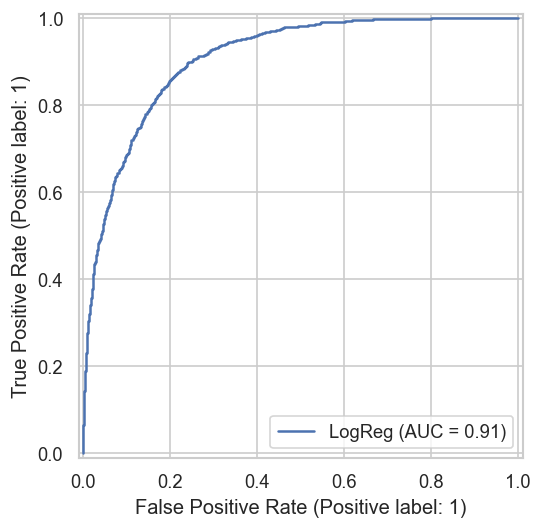

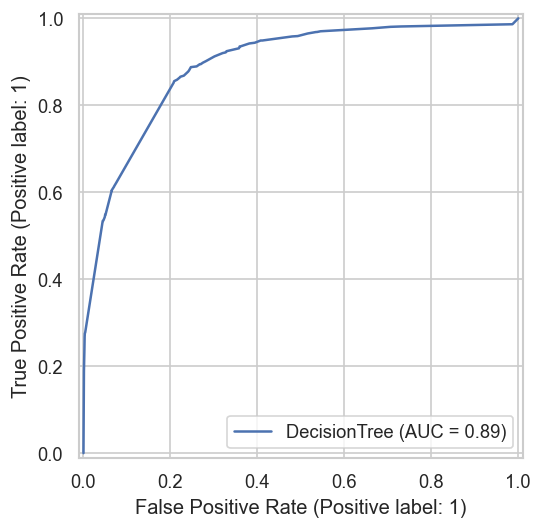

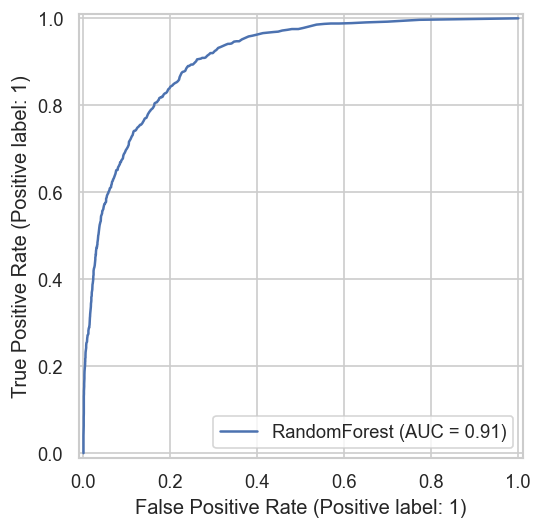

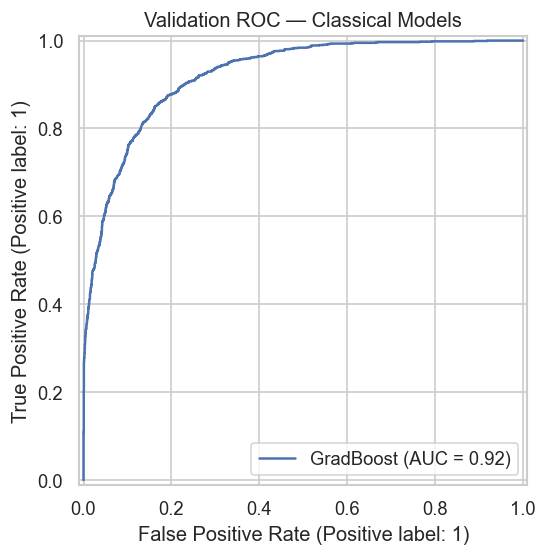

Best classical: GradBoost {
  "accuracy": 0.8667,
  "precision": 0.7933,
  "recall": 0.6037,
  "f1": 0.6857,
  "roc_auc": 0.9263
}


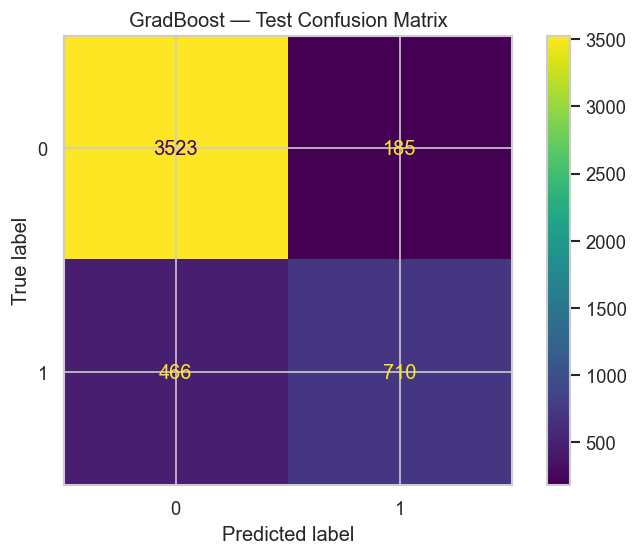

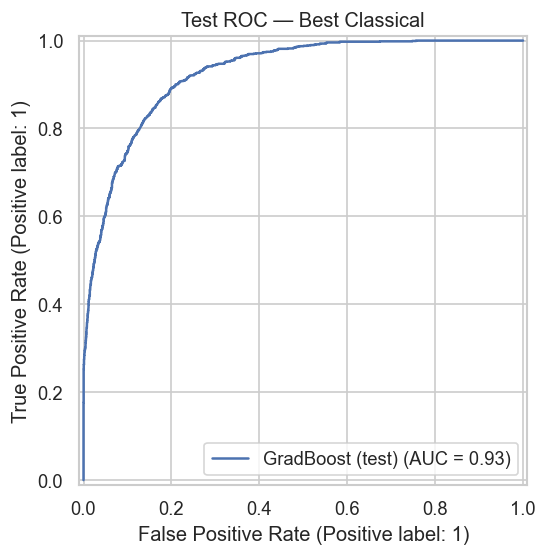

In [19]:
# preprocessing & classical models

# Preprocessor: impute+scale numerics, impute+OHE categoricals
num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')),
                     ('scaler', StandardScaler())])
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                     ('ohe', OneHotEncoder(handle_unknown='ignore'))])

pre = ColumnTransformer([('num', num_pipe, num_cols),
                         ('cat', cat_pipe, cat_cols)])

# Split data 70/15/15 
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test   = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)
print(f"Train/Val/Test sizes: {len(X_train)}/{len(X_val)}/{len(X_test)}")

def eval_metrics(y_true, y_pred, y_score):
    return dict(
        accuracy = accuracy_score(y_true, y_pred),
        precision= precision_score(y_true, y_pred, zero_division=0),
        recall   = recall_score(y_true, y_pred),
        f1       = f1_score(y_true, y_pred),
        roc_auc  = roc_auc_score(y_true, y_score)
    )

models = {
    "LogReg": LogisticRegression(max_iter=1000, n_jobs=-1, class_weight='balanced', random_state=SEED),
    "DecisionTree": DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=SEED),
    "RandomForest": RandomForestClassifier(n_estimators=300, n_jobs=-1, class_weight='balanced_subsample', random_state=SEED),
    "GradBoost": GradientBoostingClassifier(random_state=SEED)
}

val_results, roc_data = {}, {}
for name, clf in models.items():
    pipe = Pipeline([('pre', pre), ('clf', clf)])
    pipe.fit(X_train, y_train)
    y_score = pipe.predict_proba(X_val)[:,1] if hasattr(pipe[-1], "predict_proba") else pipe.decision_function(X_val)
    y_pred  = (y_score >= 0.5).astype(int)
    val_results[name] = eval_metrics(y_val, y_pred, y_score)
    roc_data[name] = (pipe, y_score, y_pred)

val_df = pd.DataFrame(val_results).T.sort_values('roc_auc', ascending=False).round(4)
display(val_df)

# ROC curves (validation)
plt.figure(figsize=(6,5))
for name,(pipe,y_score,_) in roc_data.items():
    RocCurveDisplay.from_predictions(y_val, y_score, name=name)
plt.title("Validation ROC — Classical Models"); plt.tight_layout(); plt.show()

# Pick best by ROC-AUC and test it
best_name = val_df.index[0]
best_pipe = roc_data[best_name][0]
y_score_test = best_pipe.predict_proba(X_test)[:,1] if hasattr(best_pipe[-1], "predict_proba") else best_pipe.decision_function(X_test)
y_pred_test  = (y_score_test >= 0.5).astype(int)
best_test = eval_metrics(y_test, y_pred_test, y_score_test)
print("Best classical:", best_name, json.dumps({k: round(v,4) for k,v in best_test.items()}, indent=2))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
plt.title(f"{best_name} — Test Confusion Matrix"); plt.tight_layout(); plt.show()
RocCurveDisplay.from_predictions(y_test, y_score_test, name=f"{best_name} (test)")
plt.title("Test ROC — Best Classical"); plt.tight_layout(); plt.show()


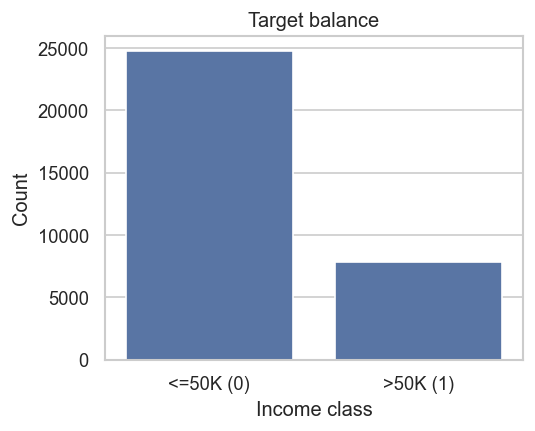

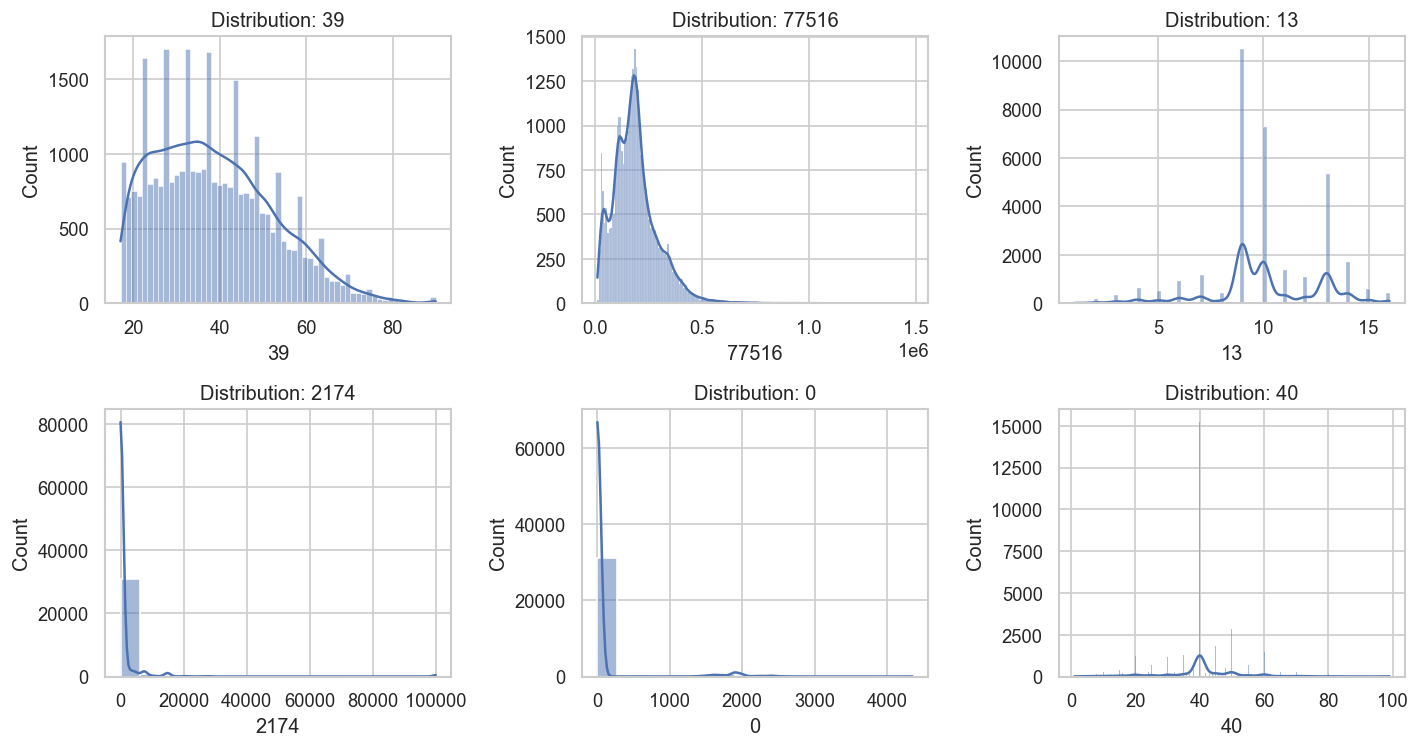

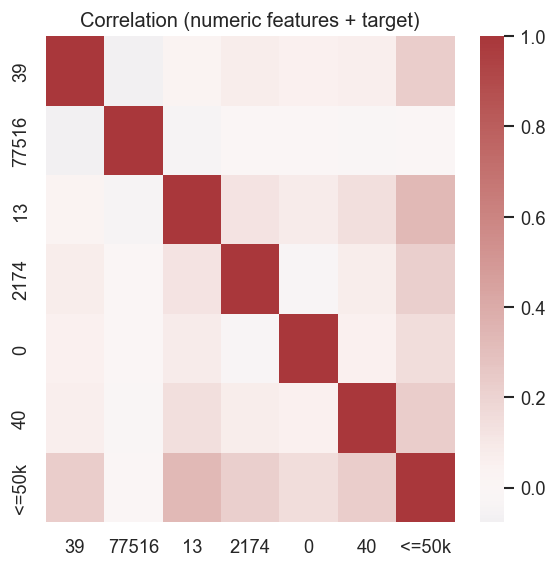

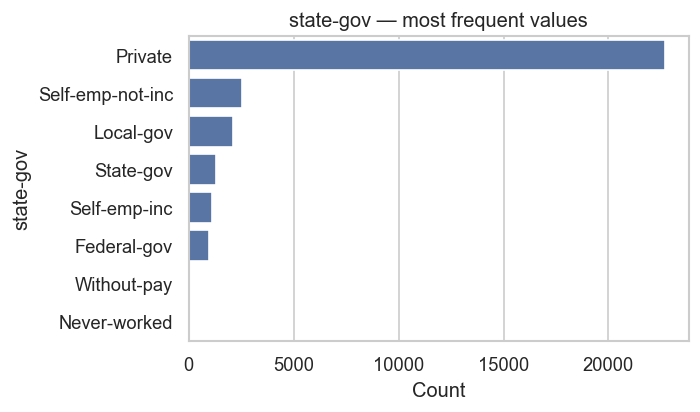

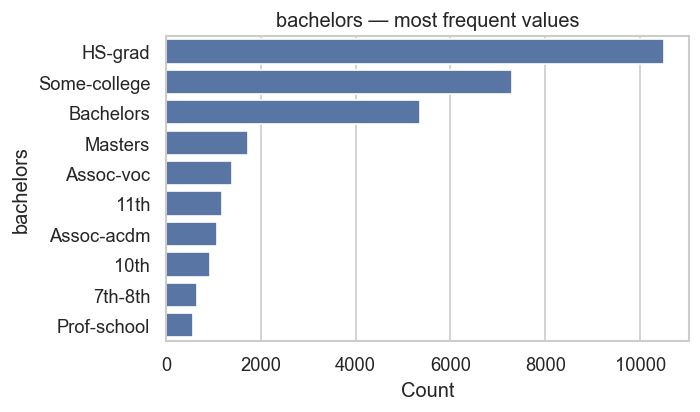

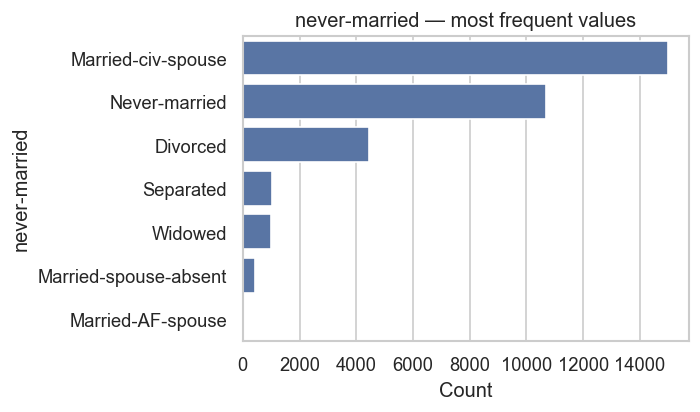

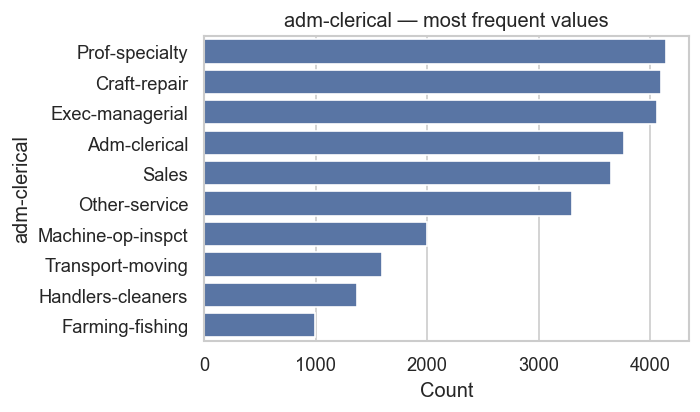

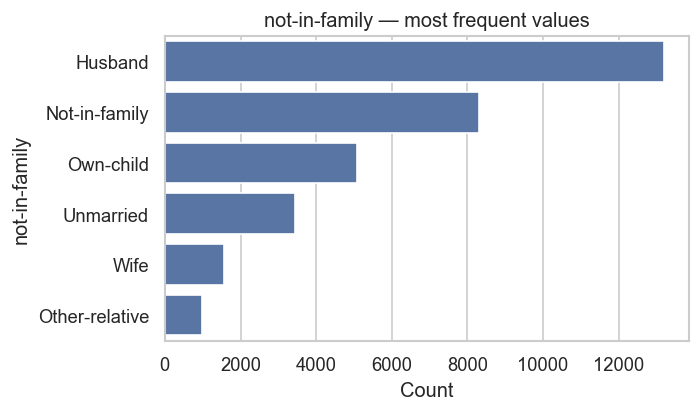

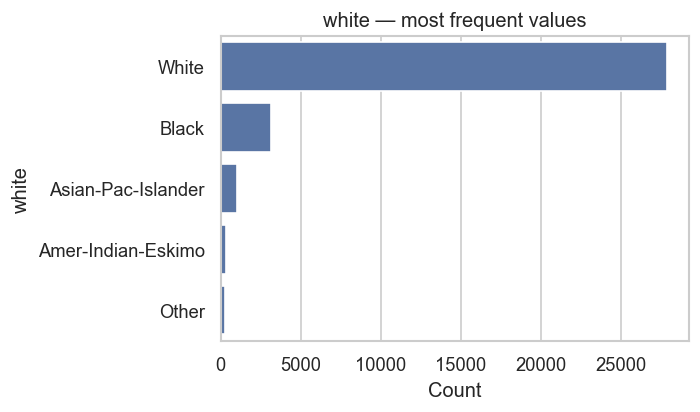

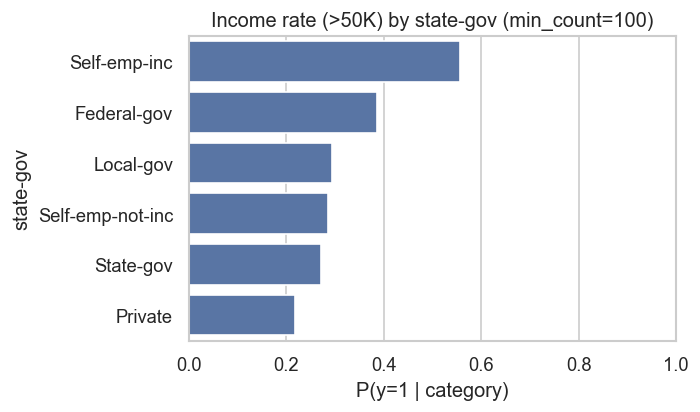

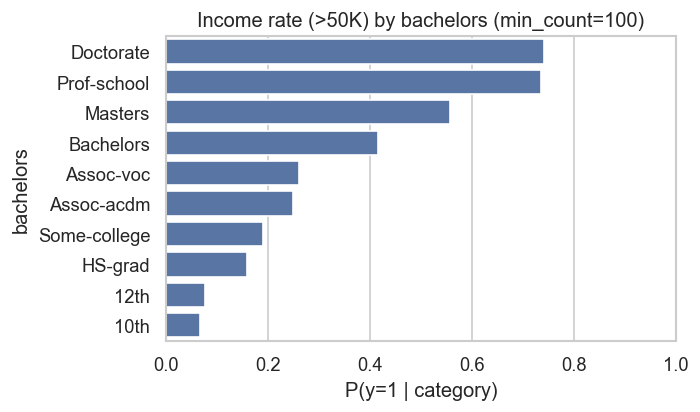

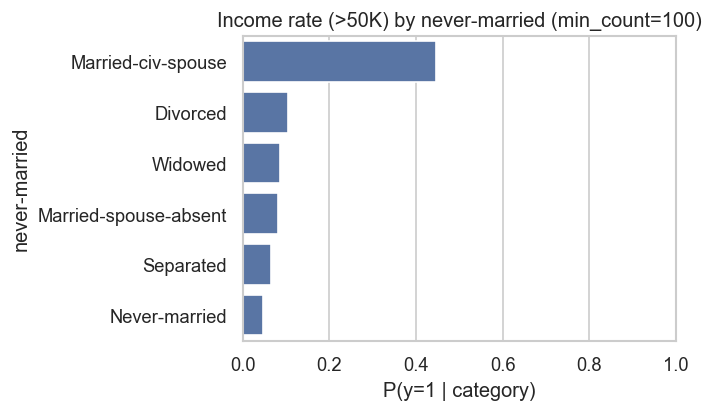

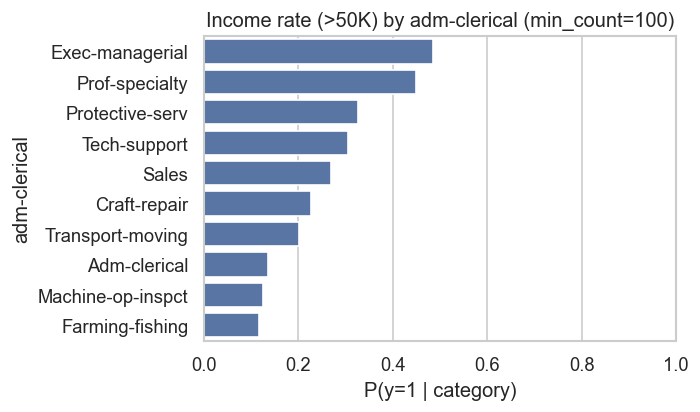

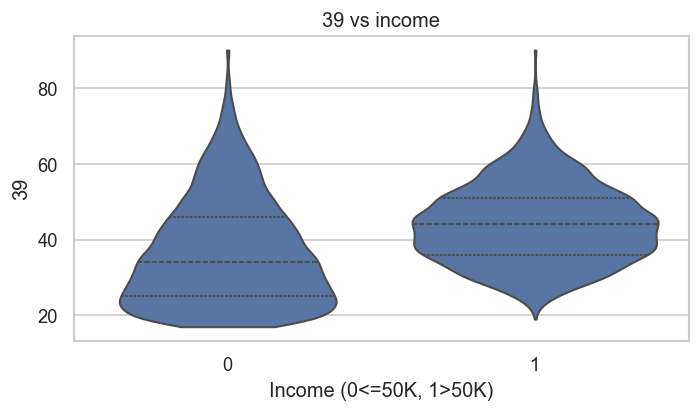

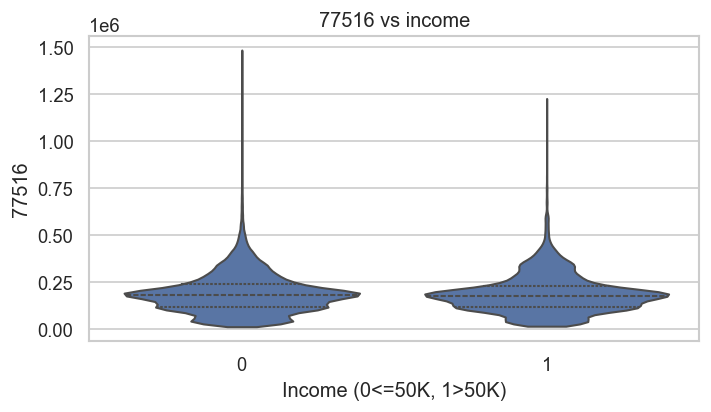

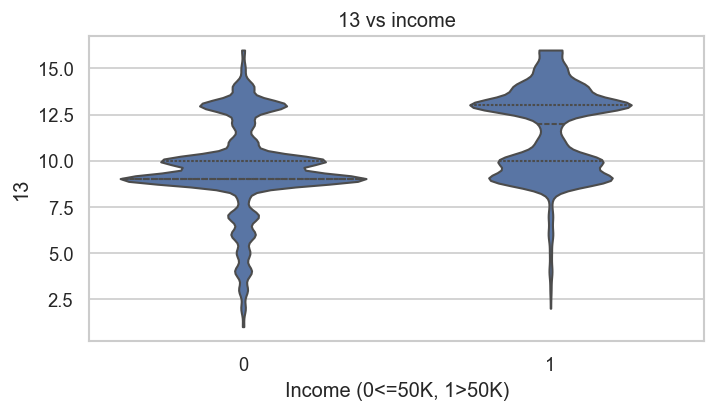

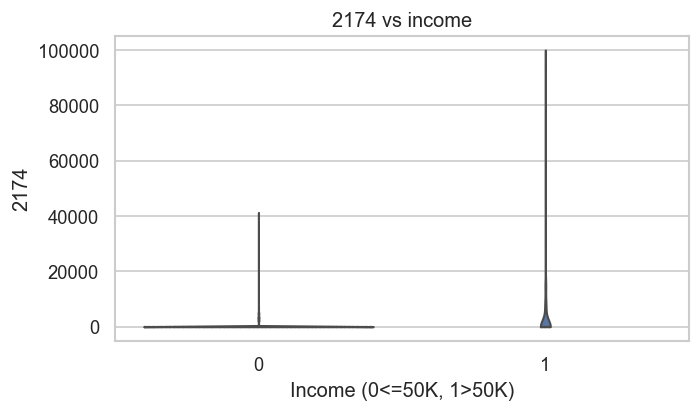

In [21]:
# EDA 

#Target balance
fig, ax = plt.subplots(figsize=(4.5,3.5))
sns.countplot(x=y, ax=ax)
ax.set_xticklabels(['<=50K (0)','>50K (1)'])
ax.set_title("Target balance")
ax.set_xlabel("Income class"); ax.set_ylabel("Count")
plt.show()

#Numeric distributions
if num_cols:
    n = min(6, len(num_cols))
    cols_show = num_cols[:n]
    rows = int(np.ceil(n/3))
    fig, axes = plt.subplots(rows, 3, figsize=(12, 3.2*rows))
    axes = np.atleast_1d(axes).ravel()
    for i, col in enumerate(cols_show):
        sns.histplot(df[col], kde=True, ax=axes[i]); axes[i].set_title(f"Distribution: {col}")
    for j in range(i+1, len(axes)): axes[j].axis('off')
    plt.tight_layout(); plt.show()

#Correlation heatmap
if len(num_cols) >= 2:
    corr = df[num_cols + [target_col]].corr(numeric_only=True)
    plt.figure(figsize=(0.7*len(corr), 0.7*len(corr)))
    sns.heatmap(corr, annot=False, cmap="vlag", center=0)
    plt.title("Correlation (numeric features + target)"); plt.tight_layout(); plt.show()

#Top categories
def top_barplot(series, top_k=10, title=None):
    vc = series.value_counts().head(top_k)
    ax = sns.barplot(x=vc.values, y=vc.index)
    ax.set_title(title or f"Top {top_k}: {series.name}")
    ax.set_xlabel("Count"); ax.set_ylabel(series.name)
    return ax

for c in cat_cols[:6]:
    plt.figure(figsize=(6,3.6))
    top_barplot(X[c], 10, title=f"{c} — most frequent values")
    plt.tight_layout(); plt.show()

# 2.5 Income rate by category (up to 4)
df_rate = X.copy(); df_rate['income'] = y.values
def plot_rate(df_in, cat, min_count=100, top_k=10):
    g = df_in.groupby(cat)['income'].agg(['mean','count']).sort_values('mean', ascending=False)
    g = g[g['count']>=min_count].head(top_k)
    plt.figure(figsize=(6,3.6))
    sns.barplot(x=g['mean'], y=g.index)
    plt.title(f"Income rate (>50K) by {cat} (min_count={min_count})")
    plt.xlabel("P(y=1 | category)"); plt.xlim(0,1); plt.ylabel(cat)
    plt.tight_layout(); plt.show()

for c in cat_cols[:4]:
    try: plot_rate(df_rate, c, 100, 10)
    except: pass

# 2.6 Numeric vs target (up to 4)
for c in num_cols[:4]:
    plt.figure(figsize=(6,3.6))
    sns.violinplot(x=y, y=X[c], inner="quartile", cut=0)
    plt.title(f"{c} vs income"); plt.xlabel("Income (0<=50K, 1>50K)")
    plt.tight_layout(); plt.show()


ANN test: {
  "accuracy": 0.8614,
  "precision": 0.7613,
  "recall": 0.6182,
  "f1": 0.6823,
  "roc_auc": 0.9192
}


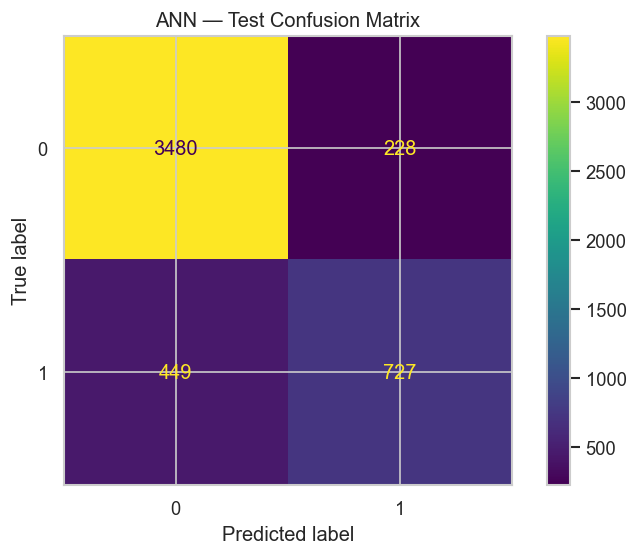

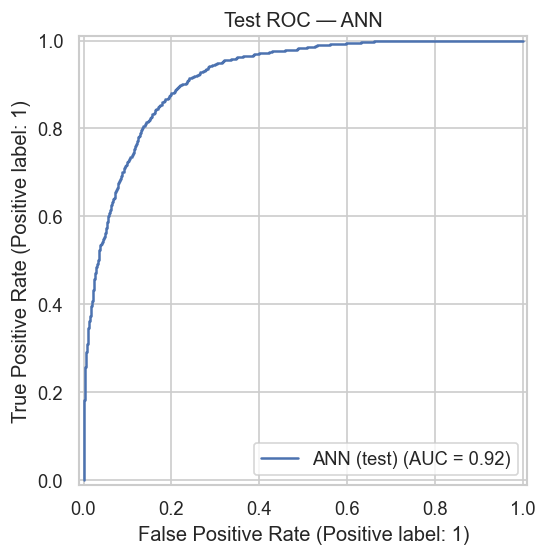

,accuracy,precision,recall,f1,roc_auc
Model,,,,,
GradBoost,0.8667,0.7933,0.6037,0.6857,0.9263
ANN,0.8614,0.7613,0.6182,0.6823,0.9192


<Figure size 720x600 with 0 Axes>

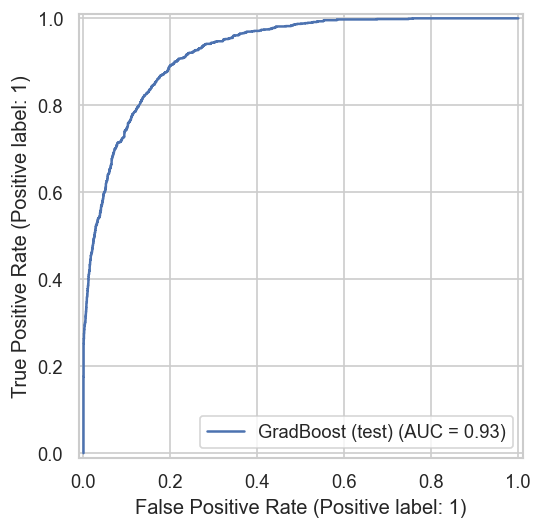

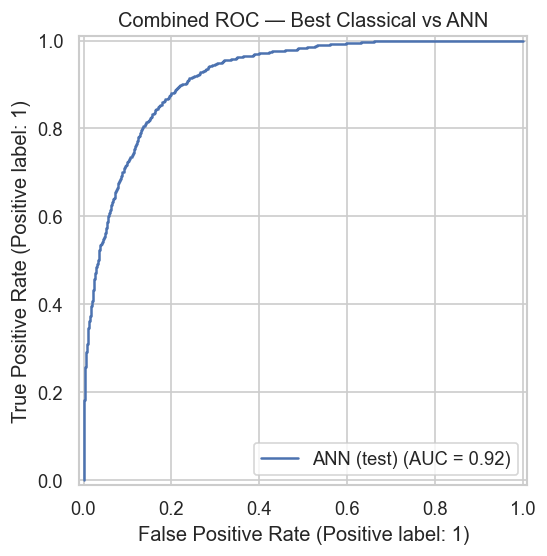

In [28]:
# ANN & comparison

pre_fitted = pre.fit(X_train)
Xtr = pre_fitted.transform(X_train)
Xva = pre_fitted.transform(X_val)
Xte = pre_fitted.transform(X_test)

# Convert sparse (from OHE) to dense for MLP
import scipy.sparse as sp
Xtr = Xtr.toarray() if sp.issparse(Xtr) else Xtr
Xva = Xva.toarray() if sp.issparse(Xva) else Xva
Xte = Xte.toarray() if sp.issparse(Xte) else Xte

ann = MLPClassifier(hidden_layer_sizes=(256,128,64),
                    activation='relu', solver='adam', alpha=1e-4,
                    batch_size=512, learning_rate_init=1e-3,
                    max_iter=50, early_stopping=True, n_iter_no_change=5,
                    random_state=SEED)
ann.fit(Xtr, y_train)

ann_score = ann.predict_proba(Xte)[:,1]
ann_pred  = (ann_score >= 0.5).astype(int)
ann_test = eval_metrics(y_test, ann_pred, ann_score)
print("ANN test:", json.dumps({k: round(v,4) for k,v in ann_test.items()}, indent=2))

ConfusionMatrixDisplay.from_predictions(y_test, ann_pred)
plt.title("ANN — Test Confusion Matrix"); plt.tight_layout(); plt.show()
RocCurveDisplay.from_predictions(y_test, ann_score, name="ANN (test)")
plt.title("Test ROC — ANN"); plt.tight_layout(); plt.show()

# Comparison table
cmp = pd.DataFrame([
    {"Model": best_name, **best_test},
    {"Model": "ANN", **ann_test}
]).set_index("Model").round(4)
display(cmp)

# Combined ROC
plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(y_test, y_score_test, name=f"{best_name} (test)")
RocCurveDisplay.from_predictions(y_test, ann_score,    name="ANN (test)")
plt.title("Combined ROC — Best Classical vs ANN"); plt.tight_layout(); plt.show()


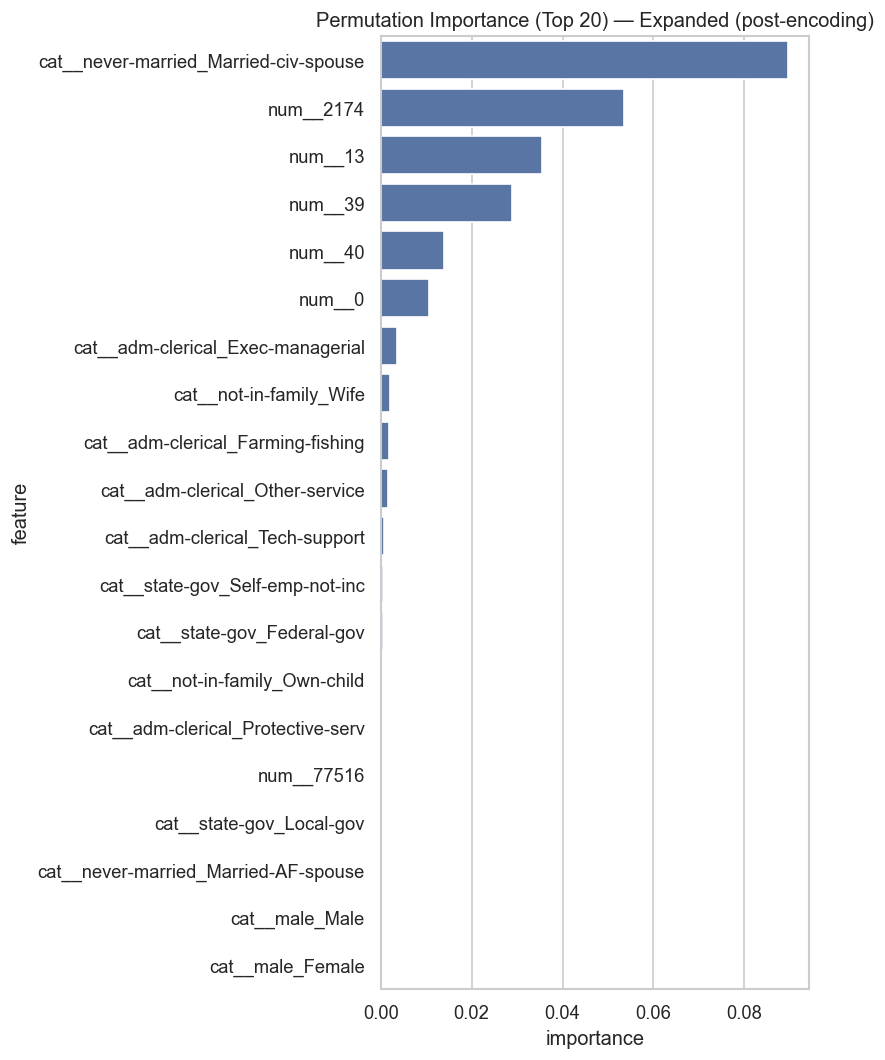

In [23]:
# Permutation

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, scipy.sparse as sp
from sklearn.inspection import permutation_importance

sns.set_theme(context="notebook", style="whitegrid")

EXPANDED_IMPORTANCE = True  
TOP_K = 20                  
MAX_SAMPLES = 5000             

if EXPANDED_IMPORTANCE:
    assert 'pre_fitted' in globals(), "pre_fitted not found (fit preprocessor in Cell 5)."
    assert 'best_pipe'   in globals(), "best_pipe not found (train classical models in Cell 4)."

    final_est = best_pipe[-1] # the trained estimator (e.g., RF/GB/LR/DT)
    X_val_tr = pre_fitted.transform(X_val) # transform validation set to model space

    if MAX_SAMPLES is not None and X_val_tr.shape[0] > MAX_SAMPLES:
        rng = np.random.default_rng(42)
        idx = rng.choice(X_val_tr.shape[0], size=MAX_SAMPLES, replace=False)
        X_val_tr = X_val_tr[idx]
        y_val_pi = y_val.iloc[idx]
    else:
        y_val_pi = y_val

    # Densify 
    if sp.issparse(X_val_tr):
        X_val_pi = X_val_tr.toarray()
    else:
        X_val_pi = np.asarray(X_val_tr)

    # Compute permutation importance in the encoded space
    perm = permutation_importance(
        final_est, X_val_pi, y_val_pi,
        n_repeats=10, random_state=SEED, scoring='roc_auc'
    )

    feat_names = pre_fitted.get_feature_names_out()
    # Align names with any subsampling 
    assert X_val_pi.shape[1] == perm.importances_mean.shape[0], \
        f"Mismatch: features={X_val_pi.shape[1]} vs importances={perm.importances_mean.shape[0]}"

    imp_df = (
        pd.DataFrame({'feature': feat_names, 'importance': perm.importances_mean})
          .sort_values('importance', ascending=False)
          .head(TOP_K)
    )

    plt.figure(figsize=(7, 0.35*len(imp_df)+2))
    sns.barplot(data=imp_df, x='importance', y='feature')
    plt.title(f'Permutation Importance (Top {TOP_K}) — Expanded (post-encoding)')
    plt.tight_layout(); plt.show()

else:
    # Input-level importance — one value per original column
    assert 'best_pipe' in globals(), "best_pipe not found (train classical models in Cell 4)."

    X_val_pi = X_val
    y_val_pi = y_val
    if MAX_SAMPLES is not None and len(X_val_pi) > MAX_SAMPLES:
        rng = np.random.default_rng(42)
        idx = rng.choice(len(X_val_pi), size=MAX_SAMPLES, replace=False)
        X_val_pi = X_val_pi.iloc[idx]
        y_val_pi = y_val_pi.iloc[idx]

    perm = permutation_importance(
        best_pipe, X_val_pi, y_val_pi,
        n_repeats=10, random_state=SEED, scoring='roc_auc'
    )

    base_feat_names = list(X_val_pi.columns)
    assert len(base_feat_names) == perm.importances_mean.shape[0], \
        f"Mismatch: columns={len(base_feat_names)} vs importances={perm.importances_mean.shape[0]}"

    imp_df = (
        pd.DataFrame({'feature': base_feat_names, 'importance': perm.importances_mean})
          .sort_values('importance', ascending=False)
          .head(TOP_K)
    )

    plt.figure(figsize=(7, 0.35*len(imp_df)+2))
    sns.barplot(data=imp_df, x='importance', y='feature')
    plt.title(f'Permutation Importance (Top {TOP_K}) — Input-level (pre-encoding)')
    plt.tight_layout(); plt.show()


KMeans vs labels — Adjusted Rand Index (ARI): 0.134


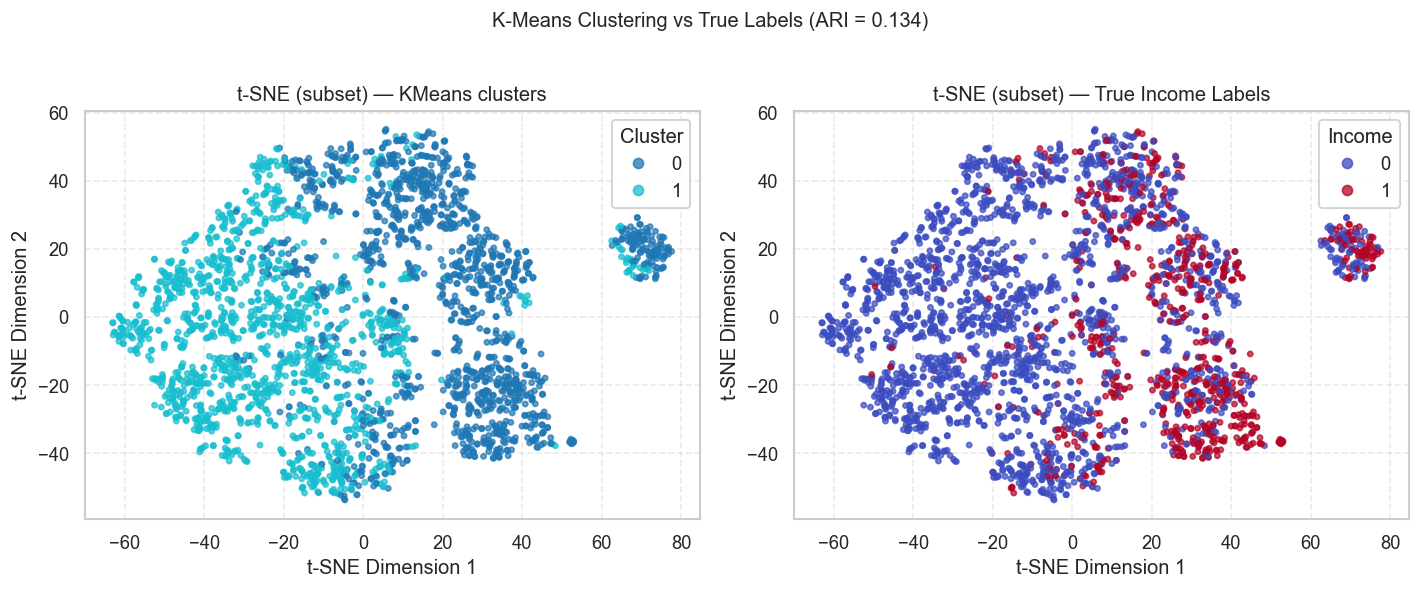

In [29]:
# K-Means clustering + visualization 

import numpy as np, matplotlib.pyplot as plt, scipy.sparse as sp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.manifold import TSNE

if 'pre_fitted' not in globals():
    pre_fitted = pre.fit(X_train)

X_all = pre_fitted.transform(pd.concat([X_train, X_val, X_test]))
y_all = pd.concat([y_train, y_val, y_test]).values
X_all_dense = X_all.toarray() if sp.issparse(X_all) else X_all

# PCA reduction
pca = PCA(n_components=min(50, X_all_dense.shape[1]), random_state=SEED)
Xp = pca.fit_transform(X_all_dense)

# KMeans clustering
km = KMeans(n_clusters=2, n_init=10, random_state=SEED).fit(Xp)
clusters = km.labels_
ari = adjusted_rand_score(y_all, clusters)
print("KMeans vs labels — Adjusted Rand Index (ARI):", round(float(ari), 3))

# t-SNE for 2D visualization 
n_plot = min(3000, len(Xp))
idx = np.random.default_rng(SEED).choice(len(Xp), size=n_plot, replace=False)
Z = TSNE(
    n_components=2, random_state=SEED, init='pca',
    perplexity=30, learning_rate='auto'
).fit_transform(Xp[idx])

# Plot t-SNE with axes, labels, and legends
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Left: KMeans clusters
sc1 = ax[0].scatter(Z[:, 0], Z[:, 1], c=clusters[idx], cmap='tab10', s=10, alpha=0.7)
ax[0].set_title("t-SNE (subset) — KMeans clusters")
ax[0].set_xlabel("t-SNE Dimension 1")
ax[0].set_ylabel("t-SNE Dimension 2")
legend1 = ax[0].legend(*sc1.legend_elements(), title="Cluster", loc="best")
ax[0].add_artist(legend1)
ax[0].grid(True, linestyle='--', alpha=0.4)

# Right: True income labels
sc2 = ax[1].scatter(Z[:, 0], Z[:, 1], c=y_all[idx], cmap='coolwarm', s=10, alpha=0.7)
ax[1].set_title("t-SNE (subset) — True Income Labels")
ax[1].set_xlabel("t-SNE Dimension 1")
ax[1].set_ylabel("t-SNE Dimension 2")
legend2 = ax[1].legend(*sc2.legend_elements(), title="Income", loc="best")
ax[1].add_artist(legend2)
ax[1].grid(True, linestyle='--', alpha=0.4)

plt.suptitle("K-Means Clustering vs True Labels (ARI = {:.3f})".format(ari), fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



Summary of Findings:

To make sure the Adult Income dataset was consistent, I removed whitespace, changed "?" entries to NaN, and encoded the target label as binary (0 for ≤$50K and 1 for >$50K). Imputed missing values (median for numeric, most-frequent for categorical) were found mostly in workclass, occupation, and native country. There were 32,560 records in the dataset, which were split into three groups: 70% for training, 15% for validation, and 15% for testing.

I used a single preprocessing pipeline to compare four classical models: Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting. The test set showed that Gradient Boosting was the best performer, with an accuracy of 0.867, a precision of 0.793, a recall of 0.604, an F1 score of 0.686, and a ROC-AUC of 0.926. The Artificial Neural Network (AUC = 0.919, F1 = 0.682) achieved similar performance but with slightly lower interpretability.

The confusion matrix (TN = 3523, FP = 185, FN = 466, TP = 710) shows that the model is very good at finding low-income individuals but misses some high-income individuals. This is normal for models that put more emphasis on precision than recall in unbalanced datasets. Permutation importance analysis identified marital/relationship status, capital gain, education level, age, and hours worked per week as the most predictive variables, consistent with established socioeconomic correlations. Using K-Means clustering on PCA-reduced data gave an Adjusted Rand Index of 0.134, which shows that unsupervised groups only loosely match income categories, which shows that class boundaries overlap.

Gradient Boosting provided the most accurate and interpretable solution. Future improvements could include class-balance adjustment, threshold tuning to improve recall, fairness assessment across demographic groups, and exploration of modern boosting frameworks such as CatBoost or LightGBM.